<a href="https://colab.research.google.com/github/deekshdechamma/DL_skill_developer/blob/main/dl12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 12: High-Dimensional Latent Space Anomaly Detection via
Convolutional Autoencoders
● Objective: Identify micro-structural patterns and outliers in manufacturing defect datasets
by mapping reconstruction error fields within structural bottlenecks.
● Required Tech Stack: PyTorch, SciPy, Scikit-Learn, Matplotlib.
● Task Description: Build a Convolutional Autoencoder featuring dense structural bottleneck
layers. Students must train the model exclusively on fault-free images, formulate custom
pixel-wise structural similarity index (SSIM) loss functions, and design an inference loop
that maps reconstruction error distributions to locate anomalies on test images

In [1]:
#Step 1 — Install Required Libraries
!pip install torch torchvision scipy scikit-learn matplotlib scikit-image

In [2]:
#Step 2 — Import Libraries
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image

from sklearn.metrics import roc_auc_score
from scipy.ndimage import gaussian_filter

from skimage.metrics import structural_similarity as ssim

In [3]:
#Step 3 — Select Device
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


In [4]:
#Step 4 — Install KaggleHub
!pip install kagglehub

In [6]:
#Step 5 — Download MVTec AD Dataset Automatically
import kagglehub
path = kagglehub.dataset_download(
    "ipythonx/mvtec-ad"
)

print("Dataset location:")
print(path)

100%|██████████| 4.91G/4.91G [00:58<00:00, 90.7MB/s]

Extracting files...


Dataset location:
/root/.cache/kagglehub/datasets/ipythonx/mvtec-ad/versions/2


In [7]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)

    if level < 3:
        print("  " * level + os.path.basename(root))

2
  transistor
    ground_truth
    test
    train
  bottle
    ground_truth
    test
    train
  wood
    ground_truth
    test
    train
  hazelnut
    ground_truth
    test
    train
  screw
    ground_truth
    test
    train
  cable
    ground_truth
    test
    train
  leather
    ground_truth
    test
    train
  grid
    ground_truth
    test
    train
  tile
    ground_truth
    test
    train
  zipper
    ground_truth
    test
    train
  capsule
    ground_truth
    test
    train
  carpet
    ground_truth
    test
    train
  metal_nut
    ground_truth
    test
    train
  toothbrush
    ground_truth
    test
    train
  pill
    ground_truth
    test
    train


In [8]:
#Step 6 — Locate Bottle Dataset
bottle_path = None

for root, dirs, files in os.walk(path):

    if os.path.basename(root).lower() == "bottle":
        bottle_path = root
        break

print("Bottle dataset:", bottle_path)

Bottle dataset: /root/.cache/kagglehub/datasets/ipythonx/mvtec-ad/versions/2/bottle


In [9]:
for root, dirs, files in os.walk(bottle_path):

    level = root.replace(
        bottle_path, ""
    ).count(os.sep)

    if level <= 2:
        print(
            "  " * level +
            os.path.basename(root)
        )

bottle
  ground_truth
    broken_small
    broken_large
    contamination
  test
    broken_small
    broken_large
    contamination
    good
  train
    good


In [10]:
#Step 7 — Find Normal Training Images
train_path = os.path.join(
    bottle_path,
    "train",
    "good"
)

train_images = []

for file in os.listdir(train_path):

    if file.lower().endswith(
        (".png", ".jpg", ".jpeg")
    ):

        train_images.append(
            os.path.join(
                train_path,
                file
            )
        )

print(
    "Number of normal training images:",
    len(train_images)
)

Number of normal training images: 209


In [11]:
#Step 8 — Define Transform
IMAGE_SIZE = 128

transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor()
])

In [12]:
#Step 9 — Create Dataset Class
class IndustrialDataset(Dataset):

    def __init__(
        self,
        image_paths,
        transform=None
    ):

        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(
        self,
        index
    ):

        image = Image.open(
            self.image_paths[index]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

In [13]:
#Step 10 — Create Training Loader
train_dataset = IndustrialDataset(
    train_images,
    transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

print(
    "Training samples:",
    len(train_dataset)
)

print(
    "Number of batches:",
    len(train_loader)
)

Training samples: 209
Number of batches: 14


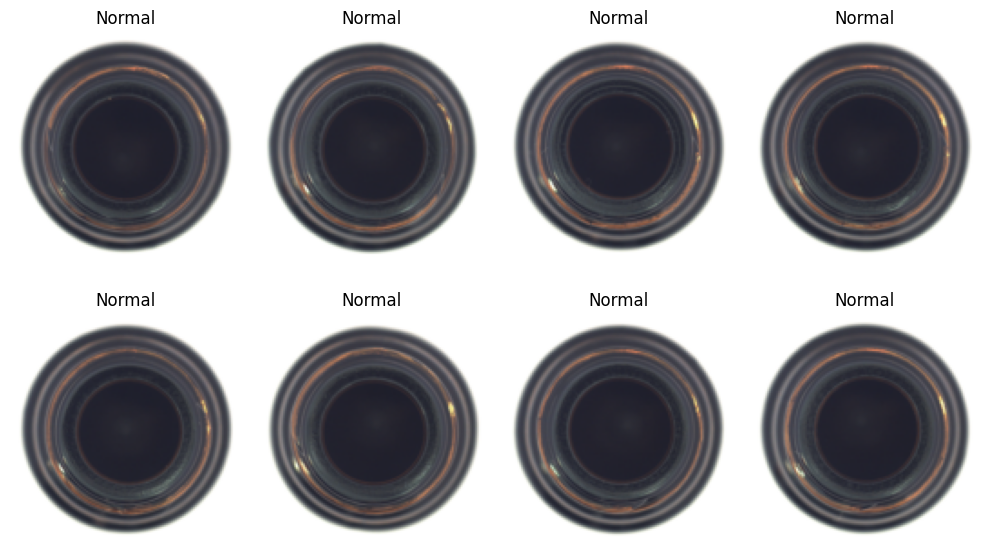

In [14]:
#Step 11 — Display Normal Images
images = next(
    iter(train_loader)
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(10, 6)
)

for i in range(8):

    image = (
        images[i]
        .permute(1, 2, 0)
        .numpy()
    )

    axes.flat[i].imshow(image)

    axes.flat[i].axis("off")

    axes.flat[i].set_title(
        "Normal"
    )

plt.tight_layout()

plt.show()

In [15]:
#Step 12 — Build Encoder
class ConvAutoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        # -----------------
        # Encoder
        # -----------------

        self.encoder = nn.Sequential(

            nn.Conv2d(
                3, 32,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU()
        )

        # 128 × 16 × 16
        self.flatten_size = (
            128 * 16 * 16
        )

        # Dense bottleneck
        self.fc_encode = nn.Linear(
            self.flatten_size,
            256
        )

        self.fc_decode = nn.Linear(
            256,
            self.flatten_size
        )

        # -----------------
        # Decoder
        # -----------------

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                32, 3,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)

        batch_size = x.size(0)

        x = x.view(
            batch_size,
            -1
        )

        latent = self.fc_encode(x)

        x = self.fc_decode(latent)

        x = x.view(
            batch_size,
            128,
            16,
            16
        )

        reconstructed = self.decoder(x)

        return reconstructed, latent

In [16]:
#Step 13 — Create Autoencoder
model = ConvAutoencoder().to(device)

print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (fc_encode): Linear(in_features=32768, out_features=256, bias=True)
  (fc_decode): Linear(in_features=256, out_features=32768, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [17]:
dummy = torch.randn(
    1,
    3,
    128,
    128
).to(device)

reconstruction, latent = model(
    dummy
)

print(
    "Input:",
    dummy.shape
)

print(
    "Reconstruction:",
    reconstruction.shape
)

print(
    "Latent representation:",
    latent.shape
)

Input: torch.Size([1, 3, 128, 128])
Reconstruction: torch.Size([1, 3, 128, 128])
Latent representation: torch.Size([1, 256])


In [18]:
#Step 14 — Create Gaussian Window
def gaussian_window(
    window_size,
    sigma
):

    coords = torch.arange(
        window_size,
        dtype=torch.float32
    )

    coords -= window_size // 2

    gaussian = torch.exp(
        -(coords ** 2) /
        (2 * sigma ** 2)
    )

    gaussian /= gaussian.sum()

    window = (
        gaussian[:, None]
        @
        gaussian[None, :]
    )

    return window

In [19]:
#Step 15 — Implement Custom SSIM
def custom_ssim(
    img1,
    img2,
    window_size=11
):

    channels = img1.size(1)

    window = gaussian_window(
        window_size,
        1.5
    )

    window = window.expand(
        channels,
        1,
        window_size,
        window_size
    ).to(img1.device)

    mu1 = F.conv2d(
        img1,
        window,
        padding=window_size // 2,
        groups=channels
    )

    mu2 = F.conv2d(
        img2,
        window,
        padding=window_size // 2,
        groups=channels
    )

    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2

    mu1_mu2 = (
        mu1 * mu2
    )

    sigma1_sq = F.conv2d(
        img1 * img1,
        window,
        padding=window_size // 2,
        groups=channels
    ) - mu1_sq

    sigma2_sq = F.conv2d(
        img2 * img2,
        window,
        padding=window_size // 2,
        groups=channels
    ) - mu2_sq

    sigma12 = F.conv2d(
        img1 * img2,
        window,
        padding=window_size // 2,
        groups=channels
    ) - mu1_mu2

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim_map = (

        (2 * mu1_mu2 + C1)
        *
        (2 * sigma12 + C2)

    ) / (

        (mu1_sq + mu2_sq + C1)
        *
        (sigma1_sq + sigma2_sq + C2)

    )

    return ssim_map

In [20]:
#Step 16 — Create Structural Loss
def ssim_loss(
    original,
    reconstructed
):

    ssim_map = custom_ssim(
        original,
        reconstructed
    )

    loss = (
        1 - ssim_map.mean()
    )

    return loss

In [21]:
test_loss = ssim_loss(
    dummy.sigmoid(),
    dummy.sigmoid()
)

print(
    "SSIM loss:",
    test_loss.item()
)

SSIM loss: 0.0


In [22]:
#Step 17 — Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

EPOCHS = 20

In [23]:
#Step 18 — Training Loop
training_losses = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for images in train_loader:

        images = images.to(device)

        reconstructed, latent = model(
            images
        )

        loss = ssim_loss(
            images,
            reconstructed
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = (
        total_loss /
        len(train_loader)
    )

    training_losses.append(
        avg_loss
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"SSIM Loss: {avg_loss:.4f}"
    )

Epoch [1/20] SSIM Loss: 0.5447
Epoch [2/20] SSIM Loss: 0.3902
Epoch [3/20] SSIM Loss: 0.1857
Epoch [4/20] SSIM Loss: 0.1208
Epoch [5/20] SSIM Loss: 0.1133
Epoch [6/20] SSIM Loss: 0.1095
Epoch [7/20] SSIM Loss: 0.1116
Epoch [8/20] SSIM Loss: 0.1119
Epoch [9/20] SSIM Loss: 0.1098
Epoch [10/20] SSIM Loss: 0.1052
Epoch [11/20] SSIM Loss: 0.1036
Epoch [12/20] SSIM Loss: 0.0974
Epoch [13/20] SSIM Loss: 0.0947
Epoch [14/20] SSIM Loss: 0.0852
Epoch [15/20] SSIM Loss: 0.0759
Epoch [16/20] SSIM Loss: 0.0719
Epoch [17/20] SSIM Loss: 0.0702
Epoch [18/20] SSIM Loss: 0.0665
Epoch [19/20] SSIM Loss: 0.0649
Epoch [20/20] SSIM Loss: 0.0633


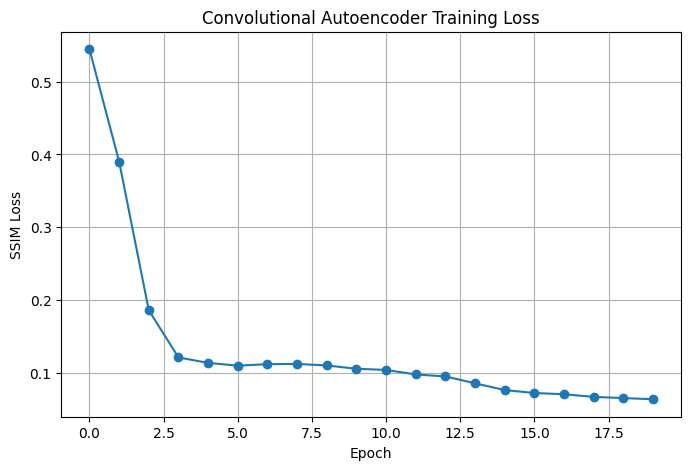

In [27]:
#Step 19 — Loss Curve
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    training_losses,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("SSIM Loss")

plt.title(
    "Convolutional Autoencoder Training Loss"
)

plt.grid()

plt.show()

In [28]:
#Step 20 — Calculate Normal Reconstruction Errors
model.eval()

normal_errors = []

with torch.no_grad():

    for images in train_loader:

        images = images.to(device)

        reconstructed, _ = model(
            images
        )

        error = torch.mean(
            (images - reconstructed) ** 2,
            dim=(1, 2, 3)
        )

        normal_errors.extend(
            error.cpu().numpy()
        )

normal_errors = np.array(
    normal_errors
)

print(
    "Mean normal error:",
    normal_errors.mean()
)

print(
    "Standard deviation:",
    normal_errors.std()
)

Mean normal error: 0.0009393598
Standard deviation: 0.00031568317


In [29]:
#Step 21 — Set Anomaly Threshold
threshold = (
    normal_errors.mean()
    +
    3 * normal_errors.std()
)

print(
    "Anomaly threshold:",
    threshold
)

Anomaly threshold: 0.0018864092


In [30]:
#Step 22 — Find Anomalous Test Images

anomaly_path = os.path.join(
    bottle_path,
    "test",
    "broken_large"
)

anomaly_images = []

for file in os.listdir(
    anomaly_path
):

    if file.lower().endswith(
        (".png", ".jpg", ".jpeg")
    ):

        anomaly_images.append(
            os.path.join(
                anomaly_path,
                file
            )
        )

print(
    "Anomaly test images:",
    len(anomaly_images)
)

Anomaly test images: 20


In [31]:
#Step 23 — Load Test Image
test_image = Image.open(
    anomaly_images[0]
).convert("RGB")

test_tensor = transform(
    test_image
)

test_tensor = (
    test_tensor
    .unsqueeze(0)
    .to(device)
)

print(
    "Test image shape:",
    test_tensor.shape
)

Test image shape: torch.Size([1, 3, 128, 128])


In [32]:
#Step 24 — Autoencoder Inference
model.eval()

with torch.no_grad():

    reconstruction, latent = model(
        test_tensor
    )

print(
    "Reconstruction:",
    reconstruction.shape
)

print(
    "Latent vector:",
    latent.shape
)

Reconstruction: torch.Size([1, 3, 128, 128])
Latent vector: torch.Size([1, 256])


In [33]:
#Step 25 — Reconstruction Error Map
error_map = torch.mean(
    torch.abs(
        test_tensor -
        reconstruction
    ),
    dim=1
)

error_map = (
    error_map
    .squeeze()
    .cpu()
    .numpy()
)

print(
    "Error map shape:",
    error_map.shape
)

Error map shape: (128, 128)


In [34]:
#Step 26 — Apply Gaussian Filter
smoothed_error = gaussian_filter(
    error_map,
    sigma=2
)

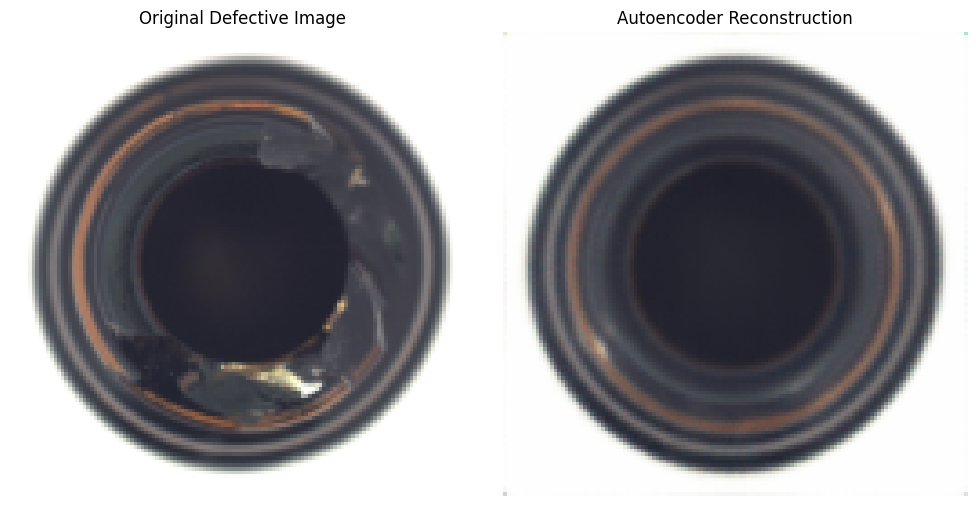

In [35]:
#Step 27 — Compare Images
original = (
    test_tensor
    .squeeze()
    .permute(1, 2, 0)
    .cpu()
    .numpy()
)

reconstructed_image = (
    reconstruction
    .squeeze()
    .permute(1, 2, 0)
    .cpu()
    .numpy()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

axes[0].imshow(original)
axes[0].set_title(
    "Original Defective Image"
)
axes[0].axis("off")

axes[1].imshow(
    reconstructed_image
)
axes[1].set_title(
    "Autoencoder Reconstruction"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

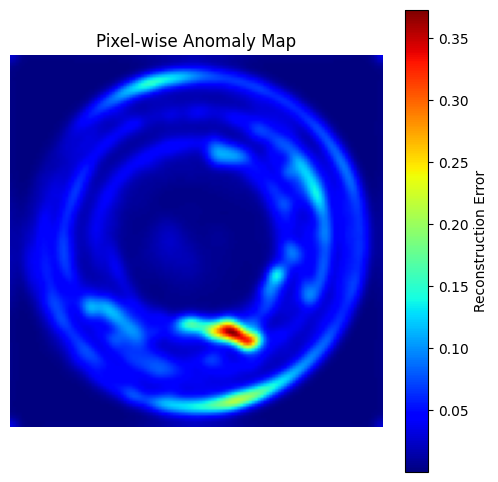

In [36]:
#Step 28 — Error Distribution
plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    smoothed_error,
    cmap="jet"
)

plt.colorbar(
    label="Reconstruction Error"
)

plt.title(
    "Pixel-wise Anomaly Map"
)

plt.axis("off")

plt.show()

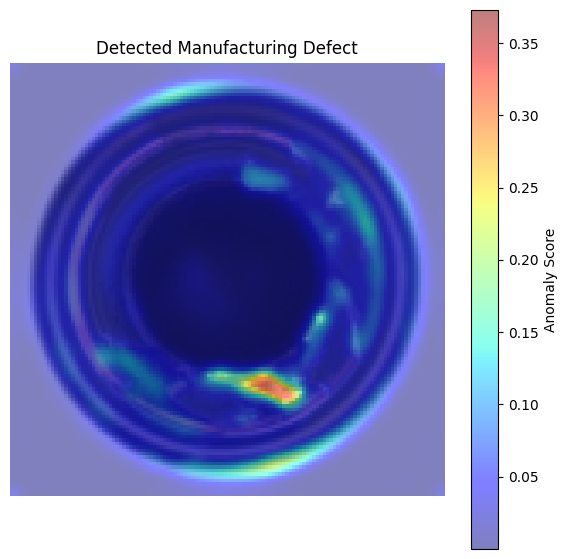

In [37]:
#Step 29 — Defect Localization
plt.figure(
    figsize=(7, 7)
)

plt.imshow(original)

plt.imshow(
    smoothed_error,
    cmap="jet",
    alpha=0.5
)

plt.colorbar(
    label="Anomaly Score"
)

plt.title(
    "Detected Manufacturing Defect"
)

plt.axis("off")

plt.show()

In [38]:
#Step 30 — Pixel Threshold
pixel_threshold = (
    smoothed_error.mean()
    +
    2 * smoothed_error.std()
)

binary_mask = (
    smoothed_error >
    pixel_threshold
)

print(
    "Pixel threshold:",
    pixel_threshold
)

Pixel threshold: 0.103769414


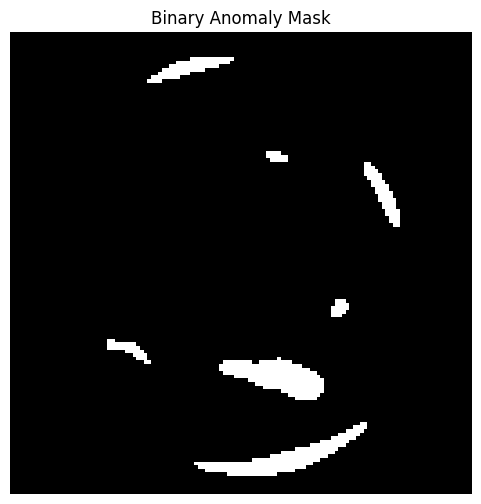

In [39]:
plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    binary_mask,
    cmap="gray"
)

plt.title(
    "Binary Anomaly Mask"
)

plt.axis("off")

plt.show()

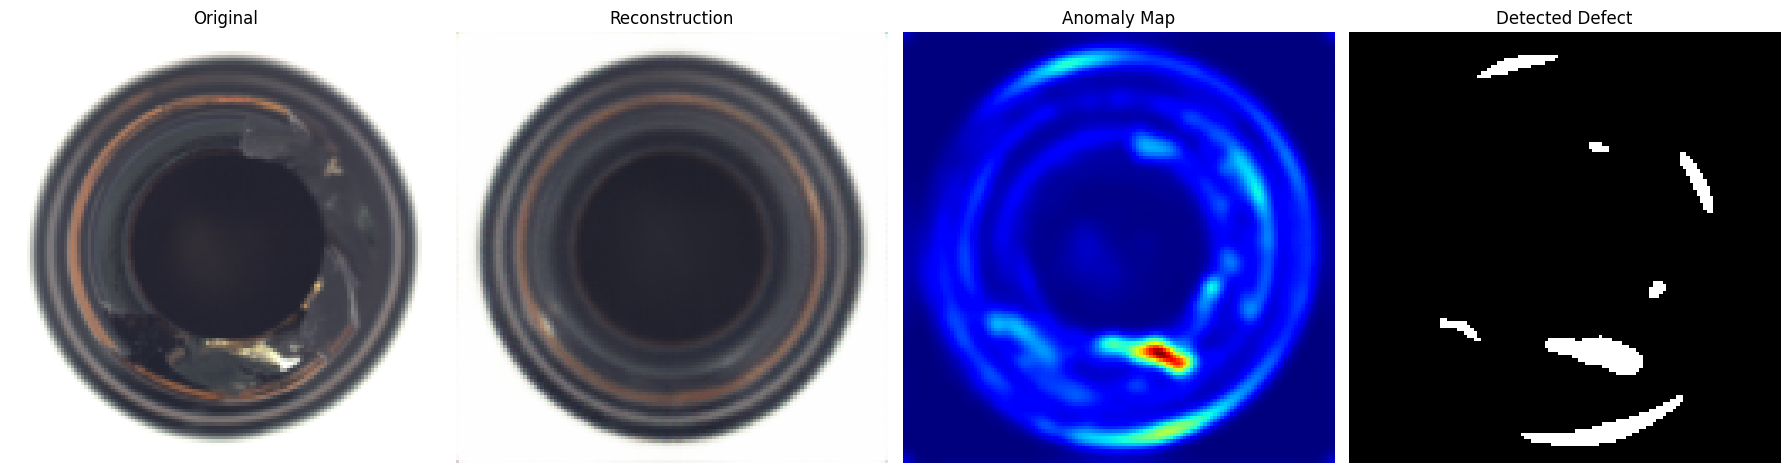

In [40]:
#Step 31 — Final Results
fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5)
)

# Original
axes[0].imshow(original)

axes[0].set_title(
    "Original"
)

axes[0].axis("off")


# Reconstruction
axes[1].imshow(
    reconstructed_image
)

axes[1].set_title(
    "Reconstruction"
)

axes[1].axis("off")


# Error map
im = axes[2].imshow(
    smoothed_error,
    cmap="jet"
)

axes[2].set_title(
    "Anomaly Map"
)

axes[2].axis("off")


# Binary mask
axes[3].imshow(
    binary_mask,
    cmap="gray"
)

axes[3].set_title(
    "Detected Defect"
)

axes[3].axis("off")


plt.tight_layout()

plt.show()

In [41]:
#Step 32 — Classify Image as Normal/Anomalous
image_error = torch.mean(
    (
        test_tensor -
        reconstruction
    ) ** 2
).item()

print(
    "Image reconstruction error:",
    image_error
)

print(
    "Threshold:",
    threshold
)

Image reconstruction error: 0.004023868124932051
Threshold: 0.0018864092


In [42]:
if image_error > threshold:

    print(
        "Result: ANOMALY DETECTED"
    )

else:

    print(
        "Result: NORMAL IMAGE"
    )

Result: ANOMALY DETECTED


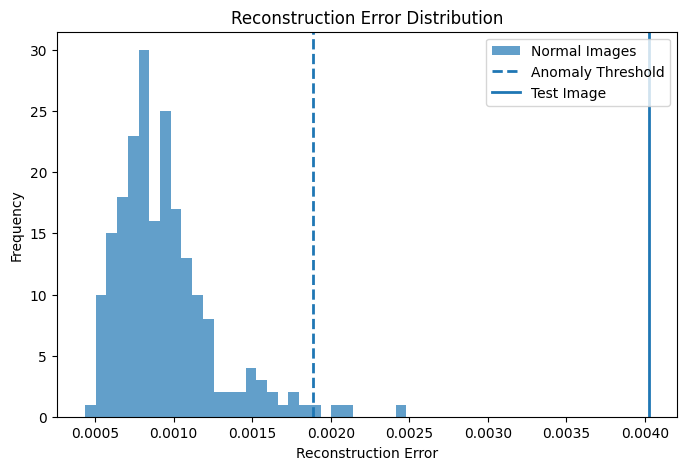

In [43]:
#Step 33 — Reconstruction Error Distribution
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    normal_errors,
    bins=30,
    alpha=0.7,
    label="Normal Images"
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="Anomaly Threshold"
)

plt.axvline(
    image_error,
    linewidth=2,
    label="Test Image"
)

plt.xlabel(
    "Reconstruction Error"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Reconstruction Error Distribution"
)

plt.legend()

plt.show()